# HOMEWORK 9

In this homework, you are going to use the dlib face detector and apply it to an image of your liking. You can follow the procedure shown in lesson 9. Please always comment your code so I can see what you're doing :-)

For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

### Step 0

Run the necessary imports.

In [225]:
import dlib
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [45, 30]

### Step 1

Load an image (any image that contains faces).

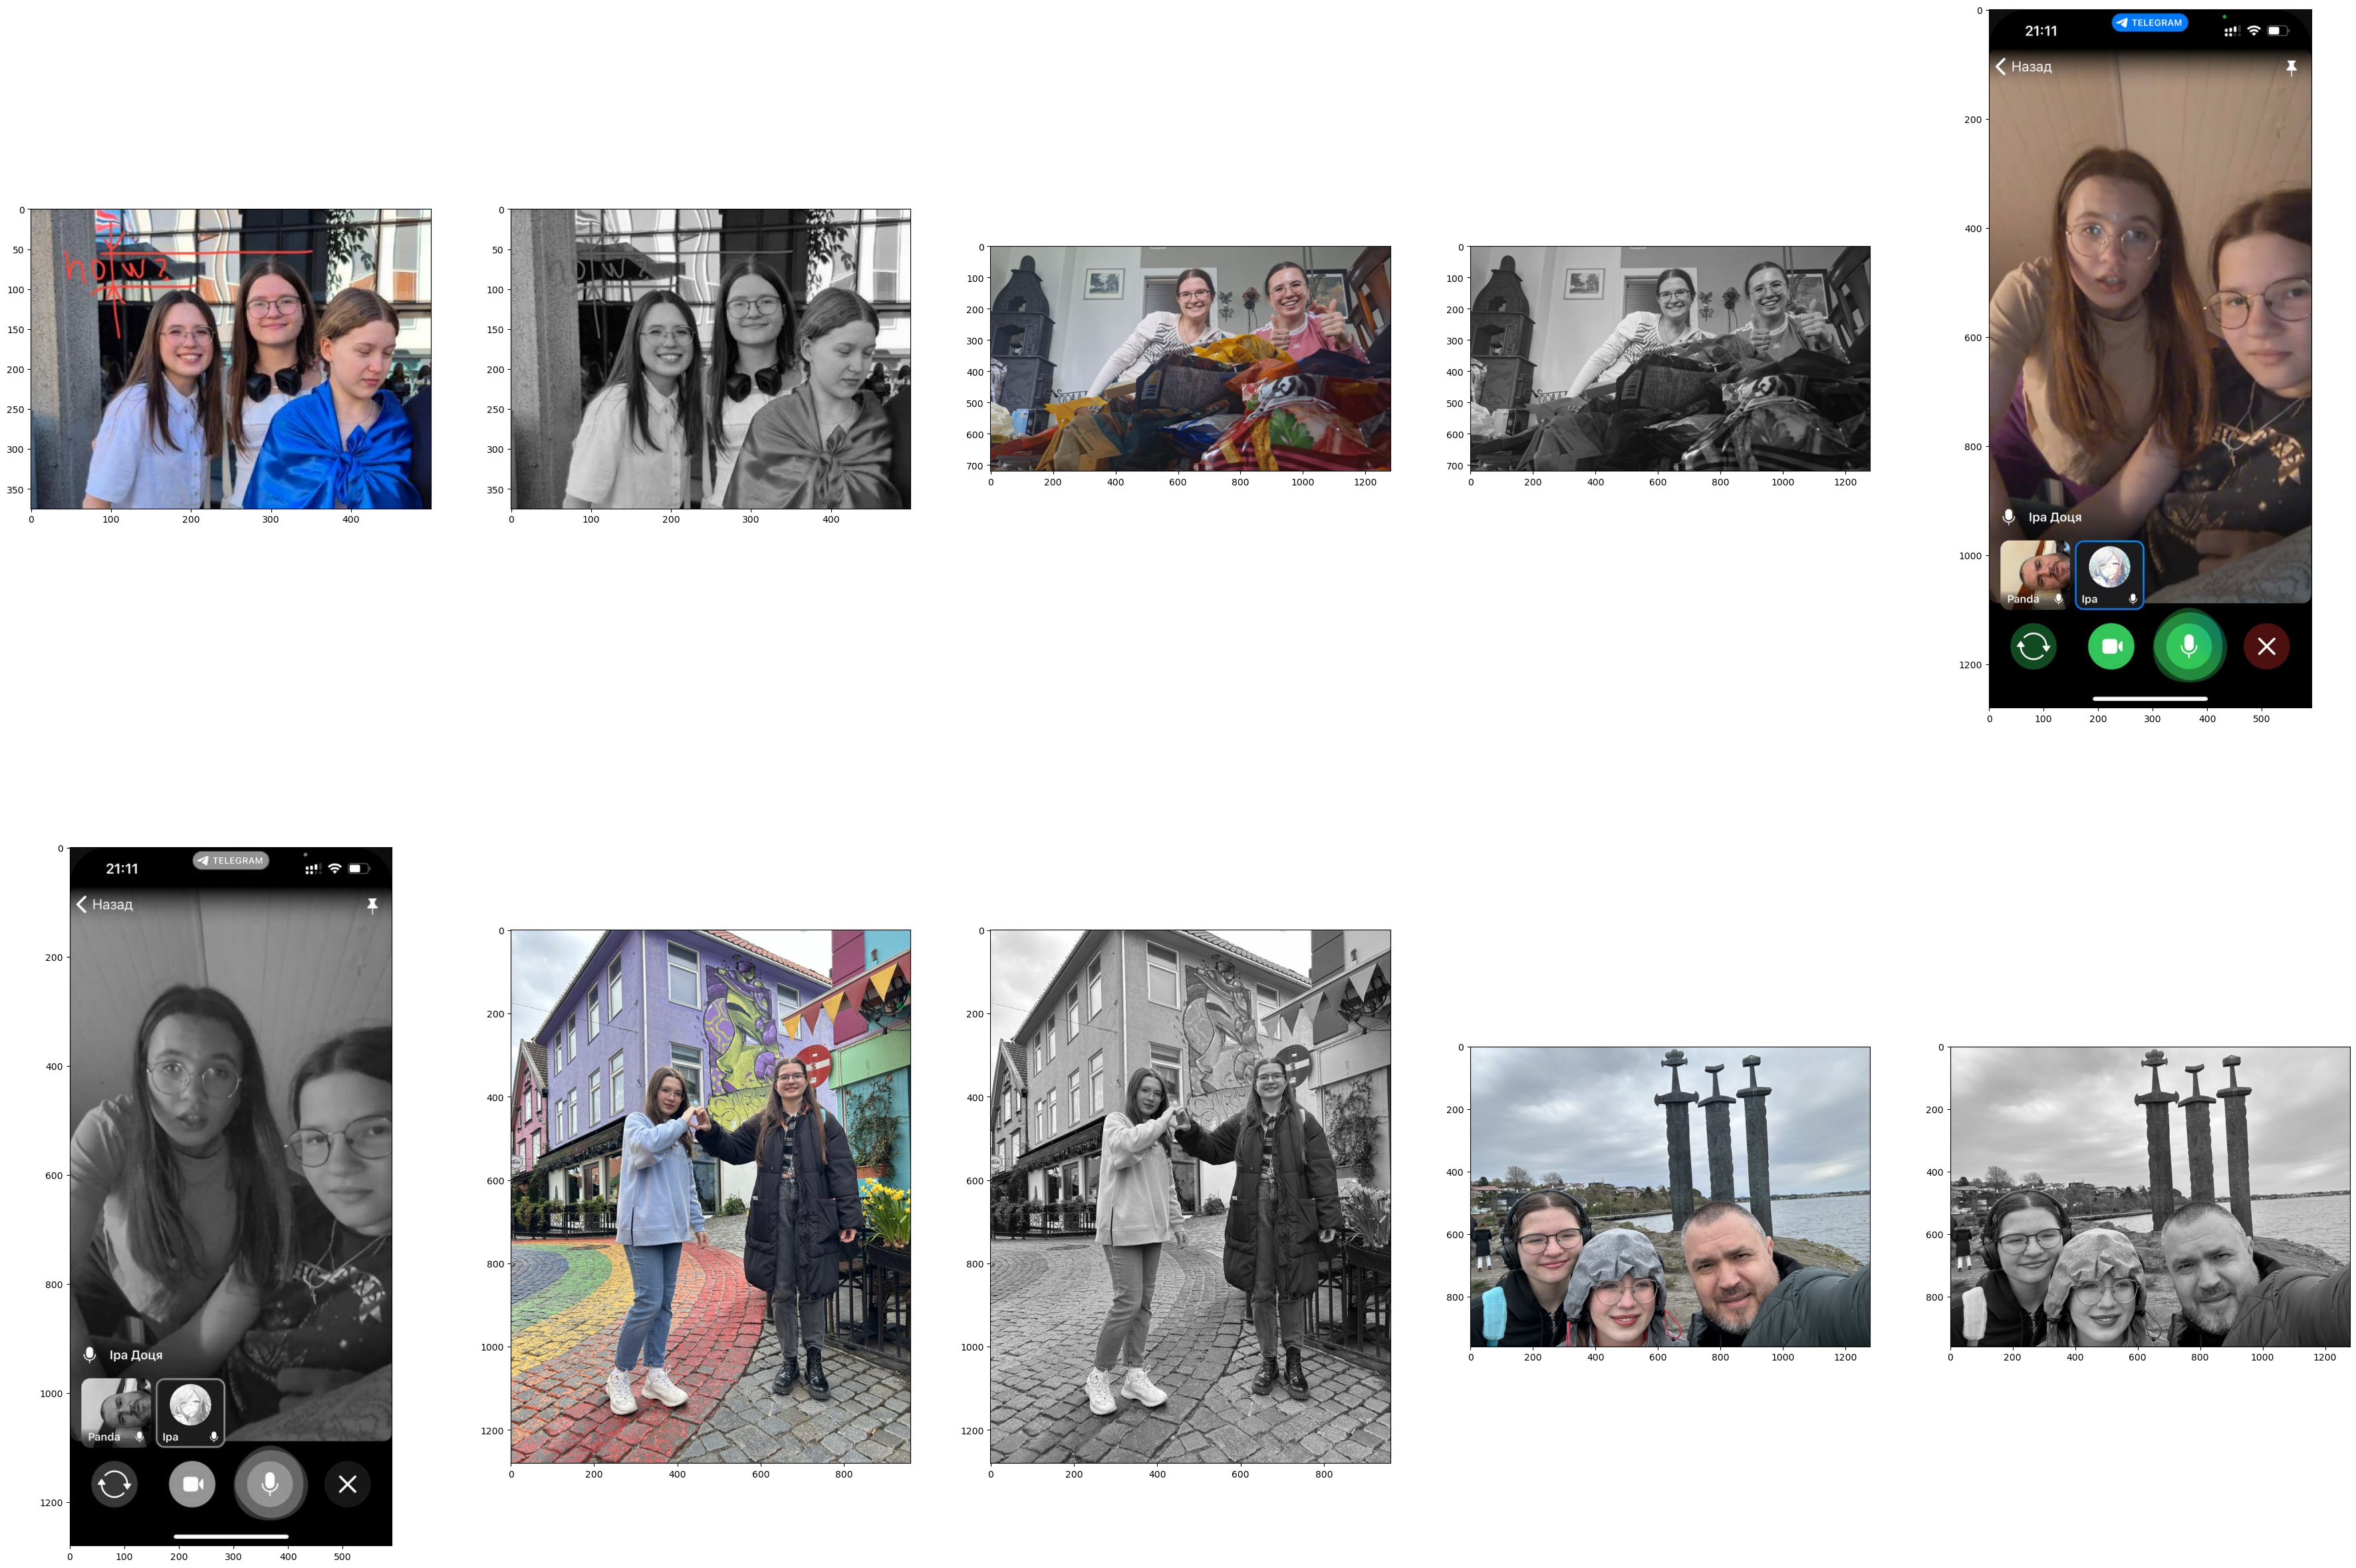

In [ ]:
image_names = ["faces1.jpg", "faces2.jpg", "faces3.jpg", "faces4.jpg", "faces5.jpg"]
images = [cv2.imread(name) for name in image_names]
images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in images]
images_gray = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in images]

for i in range(len(images)):
    plt.subplot(2, len(images), i + 1)
    plt.imshow(images[i])
    plt.subplot(2, len(images), i + 1 + len(images))
    plt.imshow(images_gray[i], cmap='gray')


### Step 2

Load the dlib face predictor.

In [227]:
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
recognizer = dlib.face_recognition_model_v1("dlib_face_recognition_resnet_model_v1.dat")

def plot_landmarks(vec, color):
    plt.plot(vec[0:17,0], vec[0:17,1], color)       # Contour
    plt.plot(vec[48:68,0], vec[48:68,1], color)     # Mouth
    plt.plot(vec[17:22,0], vec[17:22,1], color)     # Right eyebrow
    plt.plot(vec[22:27,0], vec[22:27,1], color)     # Left eyebrow
    plt.plot(np.concatenate((vec[36:42,0], vec[36:37,0])), np.concatenate((vec[36:42,1], vec[36:37,1])), color)     # Left eye
    plt.plot(np.concatenate((vec[42:48,0], vec[42:43,0])), np.concatenate((vec[42:48,1], vec[42:43,1])), color)     # Right eye
    plt.plot(vec[27:36,0], vec[27:36,1], color)     # Nose


### Step 3

Run the predictor on your image.

In [228]:
# I will be sent straight to hell with an in-depth study of OOP

# detect an face rects on each image
face_rects = [detector(img, 1) for img in images_gray]
print('face_rects:', face_rects)
# for each face rect on each image, find landmarks (dont forget to work with color image!)
landmarks = [[predictor(images[i], rect) for rect in face_rects[i]] for i in range(len(images))]
# align faces on each image
aligned_faces = [[dlib.get_face_chip(images[i], landmarks[i][j], size=150) for j in range(len(face_rects[i]))] for i in range(len(images))]
# compute face descriptors (128D vectors) for each aligned face
face_descriptors = [[recognizer.compute_face_descriptor(aligned_faces[i][j]) for j in range(len(aligned_faces[i]))] for i in range(len(images))]

cmap = plt.get_cmap("tab10")

def cosine_similarity(a, b):
    a_norm = a / np.linalg.norm(a)
    b_norm = b / np.linalg.norm(b)
    return np.dot(a_norm, b_norm)

# assign a color to each face, the same faces should have the same color
face_colors = []
color_per_vector = {}
for i in range(len(images)):
    img_face_colors = []
    face_colors.append(img_face_colors)
    for j in range(len(face_descriptors[i])):
        vec = np.array(face_descriptors[i][j])
        found = False
        for key in color_per_vector:
            if cosine_similarity(vec, key) > 0.93: # they are sisters :)
                img_face_colors.append(color_per_vector[key])
                found = True
                break
        if not found:
            color = tuple(int(c * 255) for c in cmap(len(color_per_vector))[:3])
            color_per_vector[tuple(vec)] = color
            img_face_colors.append(color)

for i in range(len(images)):
    for j, rect in enumerate(face_rects[i]):
        print(f"Image {i}, face {j}, color {face_colors[i][j]}")

face_rects: [rectangles[[(384, 146) (474, 236)], [(162, 130) (237, 204)], [(262, 96) (337, 171)]], rectangles[[(593, 128) (700, 235)], [(898, 96) (1027, 225)]], rectangles[[(117, 341) (340, 563)], [(390, 464) (613, 687)]], rectangles[[(345, 362) (419, 437)], [(635, 329) (710, 403)]], rectangles[[(142, 539) (365, 762)], [(706, 617) (973, 885)], [(390, 712) (613, 935)]]]
Image 0, face 0, color (31, 119, 180)
Image 0, face 1, color (255, 127, 14)
Image 0, face 2, color (44, 160, 44)
Image 1, face 0, color (44, 160, 44)
Image 1, face 1, color (255, 127, 14)
Image 2, face 0, color (214, 39, 40)
Image 2, face 1, color (44, 160, 44)
Image 3, face 0, color (255, 127, 14)
Image 3, face 1, color (44, 160, 44)
Image 4, face 0, color (44, 160, 44)
Image 4, face 1, color (148, 103, 189)
Image 4, face 2, color (255, 127, 14)


### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

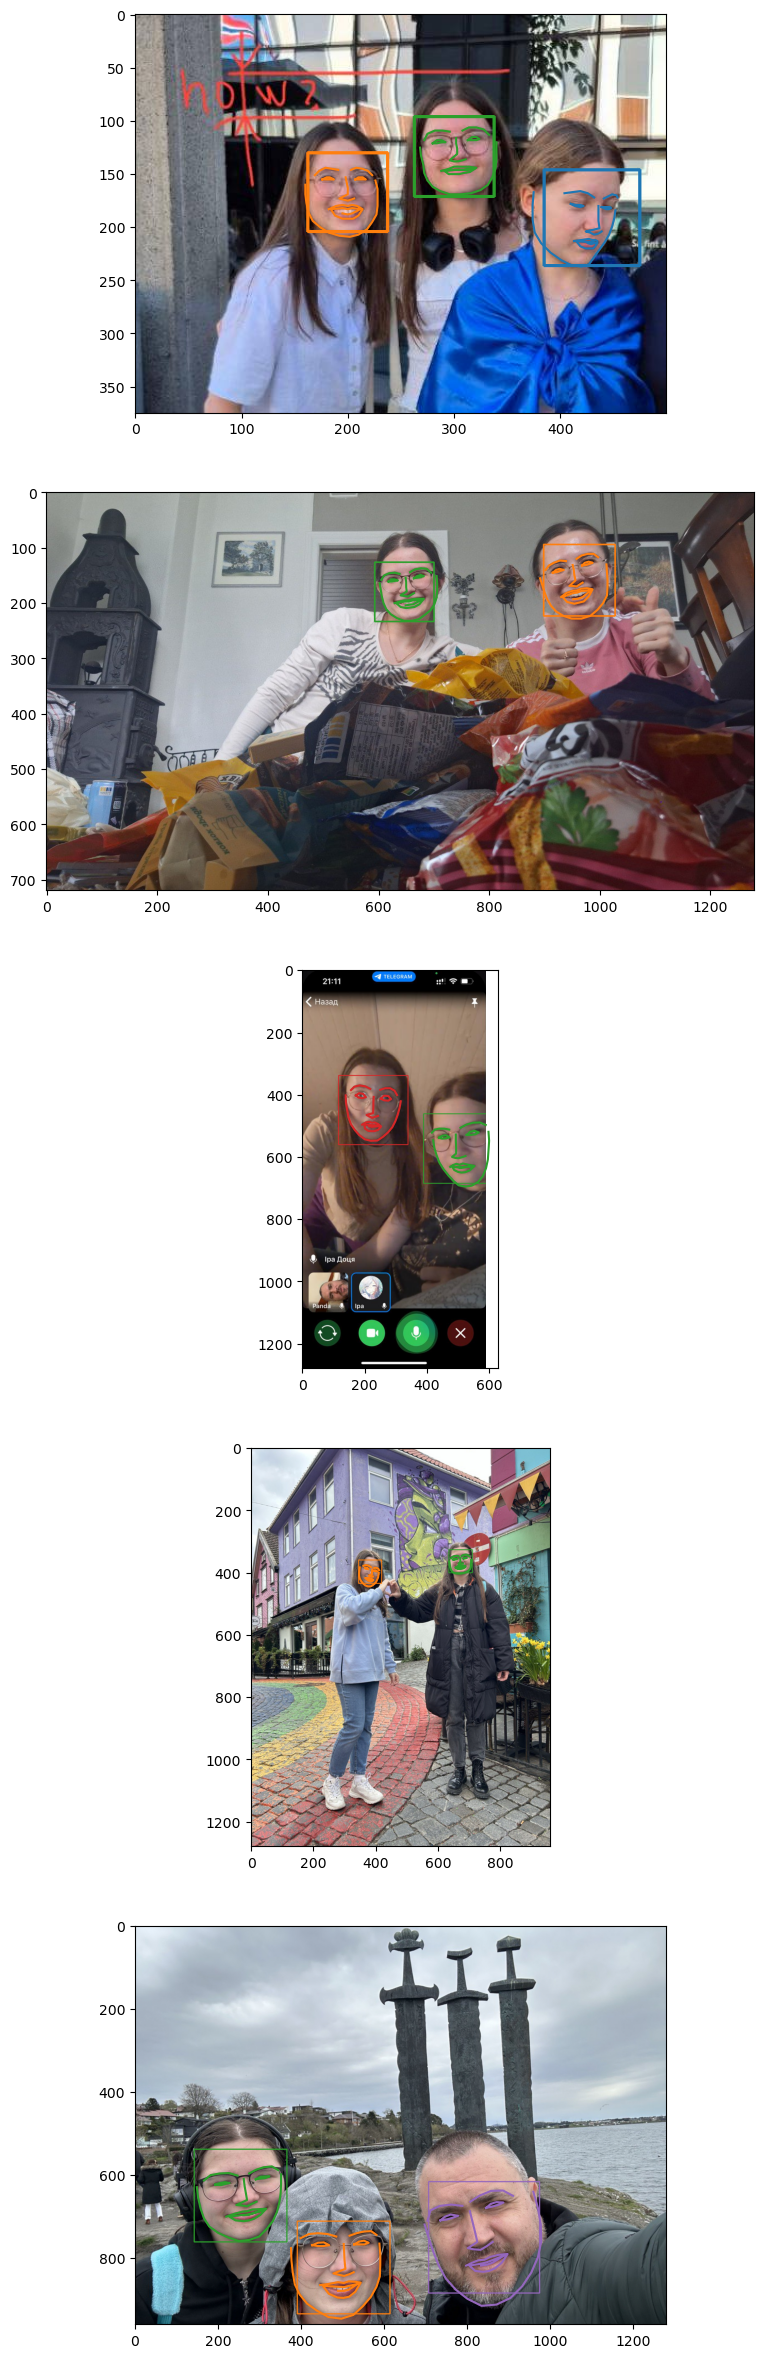

In [231]:
for i in range(len(images)):
    for j, rect in enumerate(face_rects[i]):
        x1, y1, x2, y2 = rect.left(), rect.top(), rect.right(), rect.bottom()
        cv2.rectangle(images[i], (x1, y1), (x2, y2), face_colors[i][j], 2)
    plt.subplot(len(images), 1, i + 1)
    plt.imshow(images[i])
    for j, landmark in enumerate(landmarks[i]):
        vec = np.array([[landmark.part(k).x, landmark.part(k).y] for k in range(len(landmark.parts()))])
        plot_landmarks(vec, '#%02x%02x%02x' % face_colors[i][j])

### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

I did not complete questions due to time constraints, but it was so fun to do this homework! Thanks)